In [17]:
import os 
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace, HuggingFaceEmbeddings, HuggingFaceEndpoint
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph
from typing import TypedDict
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

True

In [ ]:
llm= HuggingFaceEndpoint(
    model="Qwen/Qwen3.8-2.4T-A95B",
    huggingfacehub_api_token= os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

model= ChatHuggingFace(llm= llm)


embedding= HuggingFaceEmbeddings(model_name= "sentence-transformers/all-MiniLM-L6-v2")




Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4165.03it/s]


AIMessage(content='The Prime Minister of India is **Narendra Modi**. He has been serving as Prime Minister since May 2014 and is a member of the Bharatiya Janata Party (BJP). He won re-election in 2019 and again in 2024 for a third term.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 69, 'total_tokens': 204}, 'model_name': 'Qwen/Qwen3.8-2.4T-A95B', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0aaf8-66b3-7282-9f38-abd883014f79-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 69, 'output_tokens': 135, 'total_tokens': 204})

In [6]:
docs= (
    PyPDFLoader("./documents/book1.pdf").load() +
    PyPDFLoader("./documents/book2.pdf").load() + 
    PyPDFLoader("./documents/book3.pdf").load()
)

len(docs)

2123

In [8]:
# 2. chunks
chunks= RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3. Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content= d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [9]:
len(chunks)

6396

In [10]:
# 3) Index (fresh collection each run)

vector_store= FAISS.from_documents(chunks, embedding)

In [28]:
retriever= vector_store.as_retriever(search_type='similarity', search_kwargs={"k":4})

In [29]:
class RagState(TypedDict):
    question: str 
    docs: list[Document]
    answer: str 
    

In [30]:
def retrieve(state):
    q= state['question']
    return {"docs": retriever.invoke(q)}


PROMPT= ChatPromptTemplate.from_messages([
    ("system", "Answer only from the context. If not in context, say you don't know."),
    ("human", "Question: {question} \n\n Context: \n {context}")
])



def generation(state):
    context= "\n\n".join(d.page_content for d in state['docs'])
    parser= StrOutputParser()

    chain= PROMPT|model|parser

    out= chain.invoke({"question":state['question'], "context": context})

    return {"answer": out}

    

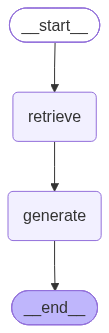

In [31]:
builder= StateGraph(RagState)

builder.add_node("retrieve", retrieve)
builder.add_node("generate", generation)

builder.add_edge("__start__", "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", "__end__")


graph= builder.compile()

graph


In [32]:
init_state={
    "question": "what is transformer in deep learning."
}

res= graph.invoke(init_state)

print(res)

{'question': 'what is transformer in deep learning.', 'docs': [Document(id='2e543ed8-123b-433f-a941-12b94761fa52', metadata={'producer': 'Antenna House PDF Output Library 6.2.609 (Linux64)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2017-03-10T21:55:34+00:00', 'author': 'Aurélien Géron', 'moddate': '2017-07-29T21:43:02+08:00', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow', 'trapped': '/False', 'source': './documents/book3.pdf', 'total_pages': 564, 'page': 82, 'page_label': '61'}, page_content='All transformers also have a convenience method called fit_transform() \nPrepare the Data for Machine Learning Algorithms | 61\n\x00D\x00o\x00w\x00n\x00l\x00o\x00a\x00d\x00 \x00f\x00r\x00o\x00m\x00 \x00f\x00i\x00n\x00e\x00l\x00y\x00b\x00o\x00o\x00k\x00 \x00w\x00w\x00w\x00.\x00f\x00i\x00n\x00e\x00l\x00y\x00b\x00o\x00o\x00k\x00.\x00c\x00o\x00m'), Document(id='cd95aec3-581d-4665-8d44-4f590d848d6c', metadata={'prod

{'question': 'what is transformer in deep learning.', 'docs': [Document(id='2e543ed8-123b-433f-a941-12b94761fa52', metadata={'producer': 'Antenna House PDF Output Library 6.2.609 (Linux64)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2017-03-10T21:55:34+00:00', 'author': 'Aurélien Géron', 'moddate': '2017-07-29T21:43:02+08:00', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow', 'trapped': '/False', 'source': './documents/book3.pdf', 'total_pages': 564, 'page': 82, 'page_label': '61'}, page_content='All transformers also have a convenience method called fit_transform() \nPrepare the Data for Machine Learning Algorithms | 61\n\x00D\x00o\x00w\x00n\x00l\x00o\x00a\x00d\x00 \x00f\x00r\x00o\x00m\x00 \x00f\x00i\x00n\x00e\x00l\x00y\x00b\x00o\x00o\x00k\x00 \x00w\x00w\x00w\x00.\x00f\x00i\x00n\x00e\x00l\x00y\x00b\x00o\x00o\x00k\x00.\x00c\x00o\x00m'), Document(id='cd95aec3-581d-4665-8d44-4f590d848d6c', metadata={'producer': 'Antenna House PDF Output Library 6.2.609 (Linux64)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2017-03-10T21:55:34+00:00', 'author': 'Aurélien Géron', 'moddate': '2017-07-29T21:43:02+08:00', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow', 'trapped': '/False', 'source': './documents/book3.pdf', 'total_pages': 564, 'page': 454, 'page_label': '433'}, page_content='9 “Stacked Convolutional Auto-Encoders for Hierarchical Feature Extraction, ” J. Masci et al. (2011).\n10 “GSNs: Generative Stochastic Networks, ” G. Alain et al. (2015).\n11 “Winner-Take-All Autoencoders, ” A. Makhzani and B. Frey (2015).\n12 “ Adversarial Autoencoders, ” A. Makhzani et al. (2016).\nStacked convolutional autoencoders9\nAutoencoders that learn to extract visual fea\ntures by reconstructing images pro‐\ncessed through convolutional layers.\nGenerative stochastic network (GSN)10\nA generalization of denoising autoencoders, with the added capability to generate\ndata.\nWinner-take-all (WTA) autoencoder11\nDuring training, after computing the activations of all the neurons in the coding\nlayer, only the top k% activations for each neuron over the training batch are pre‐\nserved, and the rest are set to zero. Naturally this leads to sparse codings. More‐'), Document(id='3a9bb8d2-6b6b-4d45-826c-203c02cc8cbe', metadata={'producer': 'Acrobat Distiller 6.0 (Windows)', 'creator': 'Adobe Acrobat 6.0', 'creationdate': '2006-10-18T12:52:36+08:00', 'author': 'Christopher M. Bishop', 'moddate': '2008-02-08T16:41:33+01:00', 'title': 'Pattern Recognition and Machine Learning', 'source': './documents/book1.pdf', 'total_pages': 758, 'page': 280, 'page_label': '261'}, page_content='ables. For example, in the classiﬁcation of objects in two-dimensional images, such\nas handwritten digits, a particular object should be assigned the same classiﬁcation\nirrespective of its position within the image ( translation invariance) or of its size\n(scale invariance ). Such transformations produce signiﬁcant changes in the raw\ndata, expressed in terms of the intensities at each of the pixels in the image, and\nyet should give rise to the same output from the classiﬁcation system. Similarly\nin speech recognition, small levels of nonlinear warping along the time axis, which\npreserve temporal ordering, should not change the interpretation of the signal.\nIf sufﬁciently large numbers of training patterns are available, then an adaptive\nmodel such as a neural network can learn the invariance, at least approximately. This'), Document(id='4cb512b2-4642-4368-bd3f-813d9eecd3bf', metadata={'producer': 'Antenna House PDF Output Library 6.2.609 (Linux64)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2017-03-10T21:55:34+00:00', 'author': 'Aurélien Géron', 'moddate': '2017-07-29T21:43:02+08:00', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow', 'trapped': '/False', 'source': './documents/book3.pdf', 'total_pages': 564, 'page': 374, 'page_label': '353'}, page_content='puppy; it’s just obvious to you. Thus, we cannot trust our subjective experience: per‐\nception is not trivial at all, and to understand it we must look at how the sensory\nmodules work.\nConvolutional neural networks (CNNs) emerged from the study of the brain’s visual\ncortex, and they have been used in image recognition since the 1980s. In the last few\nyears, thanks to the increase in computational power, the amount of available training\ndata, and the tricks presented in Chapter 11 for training deep nets, CNNs have man‐\naged to achieve superhuman performance on some complex visual tasks. They power\nimage search services, self-driving cars, automatic video classification systems, and\nmore. Moreover, CNNs are not restricted to visual perception: they are also successful\nat other tasks, such as voice recognition or natural language processing (NLP); however,')], 'answer': "I don't know."}

In [33]:
res['answer']

"I don't know."

In [35]:
context= "\n\n".join(d.page_content for d in res['docs'])

print(context)

All transformers also have a convenience method called fit_transform() 
Prepare the Data for Machine Learning Algorithms | 61
 D o w n l o a d   f r o m   f i n e l y b o o k   w w w . f i n e l y b o o k . c o m

9 “Stacked Convolutional Auto-Encoders for Hierarchical Feature Extraction, ” J. Masci et al. (2011).
10 “GSNs: Generative Stochastic Networks, ” G. Alain et al. (2015).
11 “Winner-Take-All Autoencoders, ” A. Makhzani and B. Frey (2015).
12 “ Adversarial Autoencoders, ” A. Makhzani et al. (2016).
Stacked convolutional autoencoders9
Autoencoders that learn to extract visual fea
tures by reconstructing images pro‐
cessed through convolutional layers.
Generative stochastic network (GSN)10
A generalization of denoising autoencoders, with the added capability to generate
data.
Winner-take-all (WTA) autoencoder11
During training, after computing the activations of all the neurons in the coding
layer, only the top k% activations for each neuron over the training batch are pre‐
serve